# 5ext. Sensibilità ai parametri del generatore HyperPlane: River vs CapyMOA

Questo notebook studia come tre parametri del generatore **HyperPlaneRegression** influenzano le prestazioni di **HoeffdingAdaptiveTreeRegressor (HATR)** in entrambi i framework.

**Nota metodologica:** i dati vengono generati una sola volta con `HyperPlaneRegression` di CapyMOA e materializzati in array NumPy. Entrambi i modelli (River e CapyMOA) vengono poi valutati sullo **stesso stream**, garantendo un confronto equo. Entrambi usano `StandardScaler` per la normalizzazione.

**Struttura:**
1. Setup (classpath JVM)
2. Import e helper condivisi
3. Esperimento A — variazione di `instance_random_seed`
4. Esperimento B — variazione di `number_of_drifting_attributes`
5. Esperimento C — variazione di `magnitude_of_change`
6. Tabella riassuntiva e conclusioni

> **Nota:** eseguire le celle nell'ordine da un kernel fresco. Se appare `Class not found`, riavviare il kernel e rieseguire tutto.

## 0 — Setup: classpath (deve essere eseguita prima di qualsiasi import CapyMOA)

In [1]:
import os, sys
import jpype
import jpype.config
jpype.config.destroy_jvm = False

HATR_JAR = os.path.normpath(os.path.join(os.getcwd(), '..', 'implementation',
    'hatr-moa', 'target',
    'hoeffding-adaptive-tree-regressor-moa-1.0-SNAPSHOT.jar'))
assert os.path.exists(HATR_JAR), (
    f'JAR not found: {HATR_JAR}\n'
    'run: cd implementation/hatr-moa && mvn package -DskipTests'
)

if jpype.isJVMStarted():
    print('JVM already started — Kernel → Restart & Run All')
else:
    jpype.addClassPath(HATR_JAR)
    print(f'classpath: {HATR_JAR}')

sys.path.insert(0, os.path.normpath(os.path.join(os.getcwd(), '..', 'implementation')))

classpath: /Users/andreazhang/Desktop/sda/2025-2026_Regression-Models-in-CapyMOA/andrea_zhang/implementation/hatr-moa/target/hoeffding-adaptive-tree-regressor-moa-1.0-SNAPSHOT.jar


## 1 — Import e helper condivisi

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from hatr_capymoa import HoeffdingAdaptiveTreeRegressor as CapyHATR
from capymoa.stream.generator import HyperPlaneRegression
from capymoa.instance import RegressionInstance

from river import tree as river_tree
from river import preprocessing as river_prep

# Parametri di valutazione condivisi
WINDOW_SIZE   = 200   # finestra per RMSE mobile
MAX_INSTANCES = 10_000
N_FEATURES    = 10    # uguale per entrambi i framework

print('Import OK')

Import OK


In [8]:
# ── Helper: materializzazione stream ─────────────────────────────────────────

def make_stream(instance_seed, n_drifting, mag):
    """Crea e materializza un HyperPlaneRegression in array NumPy."""
    stream = HyperPlaneRegression(
        instance_random_seed=instance_seed,
        number_of_attributes=N_FEATURES,
        number_of_drifting_attributes=n_drifting,
        magnitude_of_change=mag,
    )
    schema = stream.get_schema()
    X, y = [], []
    n = 0
    while stream.has_more_instances() and n < MAX_INSTANCES:
        inst = stream.next_instance()
        X.append(np.asarray(inst.x, dtype=float))
        y.append(float(inst.y_value))
        n += 1
    return np.array(X), np.array(y), schema


# ── Helper: loop prequenziale CapyMOA ────────────────────────────────────────

def run_capy(X, y, schema, window_size=WINDOW_SIZE):
    """Prequential HATR CapyMOA su array (X, y) con StandardScaler.
    Restituisce (windowed_rmse, cumulative_rmse)."""
    learner = CapyHATR(schema=schema, random_seed=1, bootstrap_sampling=False)
    scaler  = river_prep.StandardScaler()
    nfeat   = X.shape[1]
    errs_sq, windowed = [], []

    for i in range(len(X)):
        x_dict   = {f'x{j}': float(X[i, j]) for j in range(nfeat)}
        x_scaled = scaler.transform_one(x_dict)
        x_arr    = np.array([x_scaled.get(f'x{j}', 0.0) for j in range(nfeat)])

        inst = RegressionInstance(schema, (x_arr, float(y[i])))
        pred = learner.predict(inst) or 0.0
        scaler.learn_one(x_dict)
        learner.train(inst)

        errs_sq.append((y[i] - pred) ** 2)
        if (i + 1) % window_size == 0:
            windowed.append(np.sqrt(np.mean(errs_sq[-window_size:])))

    return np.array(windowed), float(np.sqrt(np.mean(errs_sq)))


# ── Helper: loop prequenziale River ──────────────────────────────────────────

def run_river(X, y, window_size=WINDOW_SIZE):
    """Prequential HATR River su array (X, y) con StandardScaler.
    Restituisce (windowed_rmse, cumulative_rmse)."""
    nfeat  = X.shape[1]
    model  = river_tree.HoeffdingAdaptiveTreeRegressor(seed=1, bootstrap_sampling=False)
    scaler = river_prep.StandardScaler()
    errs_sq, windowed = [], []

    for i in range(len(X)):
        x_dict   = {f'x{j}': float(X[i, j]) for j in range(nfeat)}
        x_scaled = scaler.transform_one(x_dict)
        pred = model.predict_one(x_scaled) or 0.0
        scaler.learn_one(x_dict)
        model.learn_one(x_scaled, float(y[i]))

        errs_sq.append((y[i] - pred) ** 2)
        if (i + 1) % window_size == 0:
            windowed.append(np.sqrt(np.mean(errs_sq[-window_size:])))

    return np.array(windowed), float(np.sqrt(np.mean(errs_sq)))


# ── Helper: grafico comparativo ───────────────────────────────────────────────

def plot_sweep(title, param_label, param_values, capy_curves, river_curves,
               fixed_info='', ylabel='RMSE (finestra 200 ist.)'):
    """2 pannelli affiancati (CapyMOA | River), una curva per valore del parametro."""
    x_axis = np.arange(1, MAX_INSTANCES // WINDOW_SIZE + 1) * WINDOW_SIZE
    palette = cm.plasma(np.linspace(0.1, 0.9, len(param_values)))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    for ax, curves, fw in [
            (ax1, capy_curves,  'CapyMOA (Java)'),
            (ax2, river_curves, 'River (Python)')]:
        for color, val, w in zip(palette, param_values, curves):
            ax.plot(x_axis[:len(w)], w, color=color,
                    label=f'{param_label}={val}', linewidth=1.5)
        ax.set_title(f'HATR — {fw}', fontsize=11)
        ax.set_xlabel('Istanze viste')
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    suptitle = title
    if fixed_info:
        suptitle += f'  [{fixed_info}]'
    fig.suptitle(suptitle, fontsize=12)
    plt.tight_layout()
    plt.show()


print('Helper functions defined.')

Helper functions defined.


## 2 — Esperimento A: variazione di `instance_random_seed`

Il **seme delle istanze** controlla quale sequenza di esempi viene generata. Semi diversi producono stream statisticamente equivalenti (stesso generatore, stesse statistiche marginali) ma con traiettorie diverse.

**Obiettivo:** verificare che le differenze di prestazioni tra River e CapyMOA siano **sistematiche** e non dovute a un singolo seed fortunato.

- Fissi: `magnitude_of_change=0.5`, `number_of_drifting_attributes=2`
- Semi testati: `[1, 7, 42, 100]`

Se il ranking River/CapyMOA si ripete su tutti i semi, la differenza è strutturale (implementazione Java vs Python, precisione numerica, dettagli ADWIN).

  seed=  1 ... done
  seed=  7 ... done
  seed= 42 ... done
  seed=100 ... done

RMSE cumulativo per seed (mag=0.5, n_drift=2):


,RMSE CapyMOA,RMSE River,Δ (River−Capy)
seed,,,
1,972.0861,972.0861,0.0
7,991.2412,991.2412,0.0
42,950.3901,950.3901,0.0
100,1279.6349,1279.6349,0.0


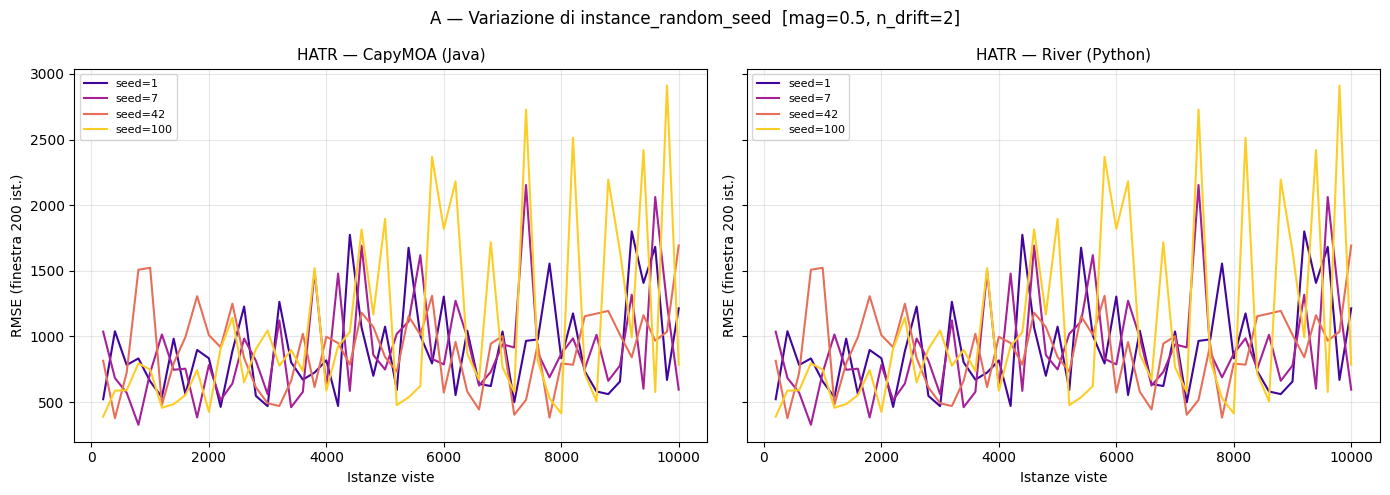

In [9]:
SEEDS_A   = [1, 7, 42, 100]
NDRIFT_A  = 2
MAG_A     = 0.5

rows_a, capy_a, river_a = [], [], []

for s in SEEDS_A:
    print(f'  seed={s:>3} ...', end=' ', flush=True)
    X, y, schema = make_stream(s, NDRIFT_A, MAG_A)
    wc, rc = run_capy(X, y, schema)
    wr, rr = run_river(X, y)
    capy_a.append(wc);  river_a.append(wr)
    rows_a.append({'seed': s,
                   'RMSE CapyMOA': round(rc, 4),
                   'RMSE River':   round(rr, 4),
                   'Δ (River−Capy)': round(rr - rc, 4)})
    print('done')

df_a = pd.DataFrame(rows_a).set_index('seed')
print('\nRMSE cumulativo per seed (mag=0.5, n_drift=2):')
display(df_a)

plot_sweep(
    title='A — Variazione di instance_random_seed',
    param_label='seed',
    param_values=SEEDS_A,
    capy_curves=capy_a,
    river_curves=river_a,
    fixed_info='mag=0.5, n_drift=2'
)

## 3 — Esperimento B: variazione di `number_of_drifting_attributes`

`number_of_drifting_attributes` (CapyMOA) / `n_drift_features` (River) controlla **quanti pesi dell'hyperplano cambiano** ad ogni passo del generatore.

| Valore | Significato |
|---|---|
| `0` | Stream stazionario: nessun peso cambia |
| `2` | Default: 2 attributi su 10 in deriva |
| `5` | Metà degli attributi in deriva |
| `10` | Tutti gli attributi cambiano → deriva massima |

**Atteso:** con più attributi in deriva il concetto cambia più velocemente → RMSE più alto. HATR, grazie agli ADWIN per nodo, dovrebbe adattarsi meglio rispetto a un albero senza drift detection.

- Fissi: `instance_random_seed=1`, `magnitude_of_change=0.5`

  n_drifting= 0 ... done
  n_drifting= 2 ... done
  n_drifting= 5 ... done
  n_drifting=10 ... done

RMSE cumulativo per n_drifting (seed=1, mag=0.5):


,RMSE CapyMOA,RMSE River,Δ (River−Capy)
n_drifting,,,
0,17.9409,17.9409,0.0
2,972.0861,972.0861,0.0
5,1953.3672,1953.3672,0.0
10,2261.1666,2261.1666,0.0


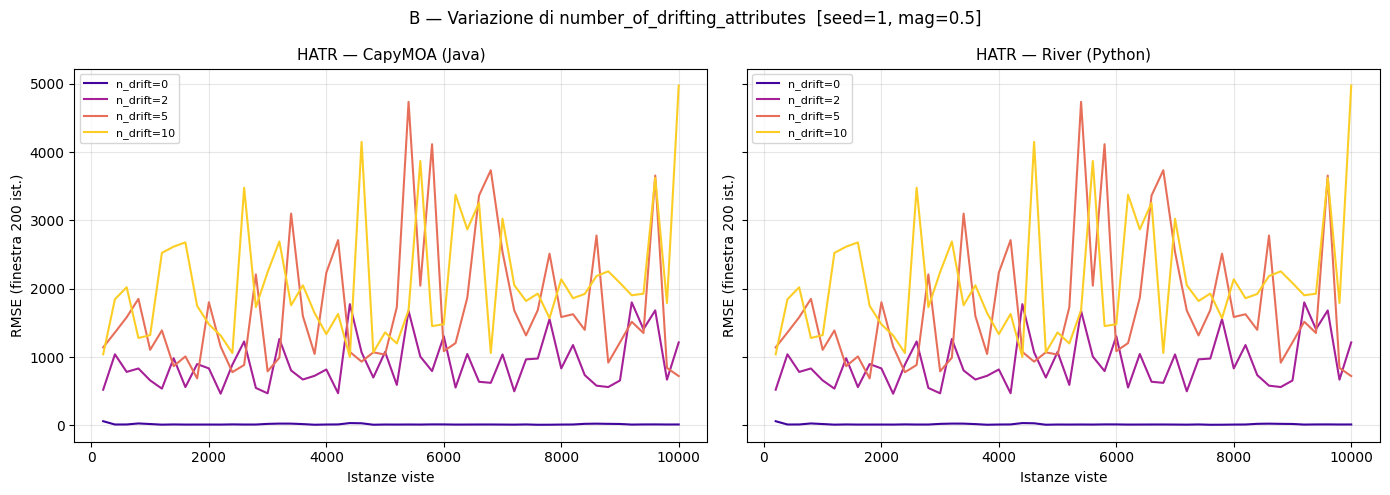

In [10]:
NDRIFT_VALUES = [0, 2, 5, 10]
SEED_B        = 1
MAG_B         = 0.5

rows_b, capy_b, river_b = [], [], []

for nd in NDRIFT_VALUES:
    print(f'  n_drifting={nd:>2} ...', end=' ', flush=True)
    X, y, schema = make_stream(SEED_B, nd, MAG_B)
    wc, rc = run_capy(X, y, schema)
    wr, rr = run_river(X, y)
    capy_b.append(wc);  river_b.append(wr)
    rows_b.append({'n_drifting': nd,
                   'RMSE CapyMOA': round(rc, 4),
                   'RMSE River':   round(rr, 4),
                   'Δ (River−Capy)': round(rr - rc, 4)})
    print('done')

df_b = pd.DataFrame(rows_b).set_index('n_drifting')
print('\nRMSE cumulativo per n_drifting (seed=1, mag=0.5):')
display(df_b)

plot_sweep(
    title='B — Variazione di number_of_drifting_attributes',
    param_label='n_drift',
    param_values=NDRIFT_VALUES,
    capy_curves=capy_b,
    river_curves=river_b,
    fixed_info='seed=1, mag=0.5'
)

## 4 — Esperimento C: variazione di `magnitude_of_change`

`magnitude_of_change` (CapyMOA) / `mag_change` (River) controlla **di quanto i pesi dell'hyperplano cambiano ad ogni singola istanza**.

| Valore | Effetto |
|---|---|
| `0.0` | Stream stazionario (nessuna deriva) |
| `0.1` | Deriva lenta: il modello ha molte istanze per adattarsi |
| `0.5` | Deriva moderata (usata negli esperimenti A e B) |
| `1.0` | Deriva rapida: il concetto cambia drasticamente ad ogni passo |

**Atteso:** RMSE minimo con `mag=0.0` (stream stabile). Con magnitudini crescenti l'RMSE in finestra tende a restare alto o a oscillare. HATR risponde attivando l'alternate tree nei nodi dove ADWIN segnala deriva.

- Fissi: `instance_random_seed=1`, `number_of_drifting_attributes=2`

  mag=0.0 ... done
  mag=0.1 ... done
  mag=0.5 ... done
  mag=1.0 ... done

RMSE cumulativo per magnitude_of_change (seed=1, n_drift=2):


,RMSE CapyMOA,RMSE River,Δ (River−Capy)
magnitude,,,
0.0,15.5329,15.5329,0.0
0.1,200.1152,200.1152,0.0
0.5,972.0861,972.0861,0.0
1.0,1937.7824,1937.7824,0.0


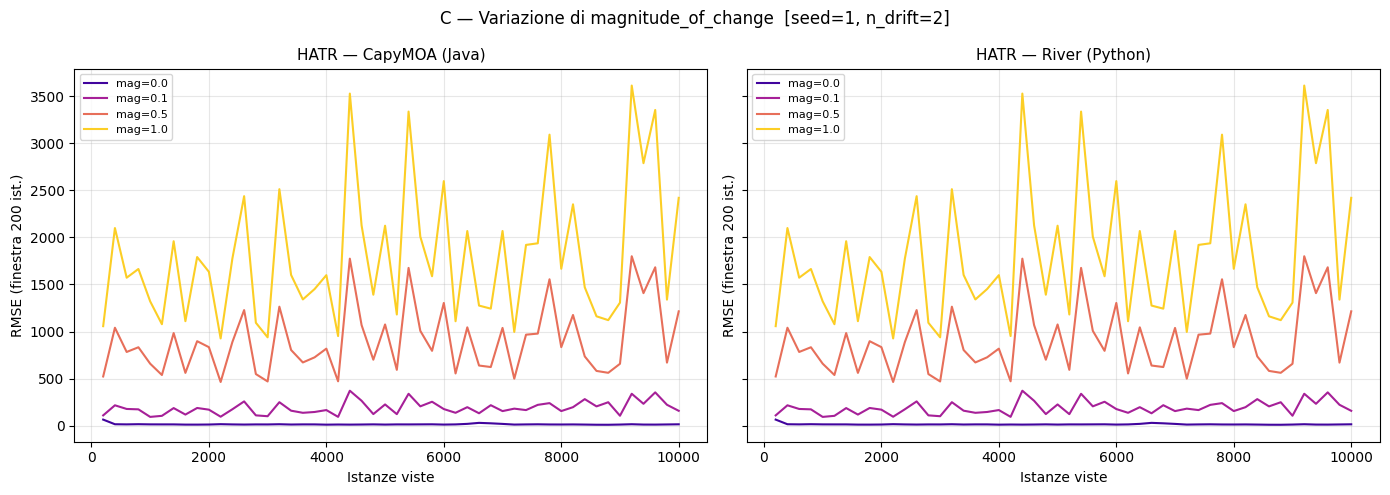

In [11]:
MAG_VALUES = [0.0, 0.1, 0.5, 1.0]
SEED_C     = 1
NDRIFT_C   = 2

rows_c, capy_c, river_c = [], [], []

for mag in MAG_VALUES:
    print(f'  mag={mag} ...', end=' ', flush=True)
    X, y, schema = make_stream(SEED_C, NDRIFT_C, mag)
    wc, rc = run_capy(X, y, schema)
    wr, rr = run_river(X, y)
    capy_c.append(wc);  river_c.append(wr)
    rows_c.append({'magnitude': mag,
                   'RMSE CapyMOA': round(rc, 4),
                   'RMSE River':   round(rr, 4),
                   'Δ (River−Capy)': round(rr - rc, 4)})
    print('done')

df_c = pd.DataFrame(rows_c).set_index('magnitude')
print('\nRMSE cumulativo per magnitude_of_change (seed=1, n_drift=2):')
display(df_c)

plot_sweep(
    title='C — Variazione di magnitude_of_change',
    param_label='mag',
    param_values=MAG_VALUES,
    capy_curves=capy_c,
    river_curves=river_c,
    fixed_info='seed=1, n_drift=2'
)

## 5 — Tabella riassuntiva

In [12]:
print('═' * 55)
print('A — instance_random_seed  (mag=0.5, n_drift=2)')
print('═' * 55)
display(df_a)

print('\n' + '═' * 55)
print('B — number_of_drifting_attributes  (seed=1, mag=0.5)')
print('═' * 55)
display(df_b)

print('\n' + '═' * 55)
print('C — magnitude_of_change  (seed=1, n_drift=2)')
print('═' * 55)
display(df_c)

═══════════════════════════════════════════════════════
A — instance_random_seed  (mag=0.5, n_drift=2)
═══════════════════════════════════════════════════════


,RMSE CapyMOA,RMSE River,Δ (River−Capy)
seed,,,
1,972.0861,972.0861,0.0
7,991.2412,991.2412,0.0
42,950.3901,950.3901,0.0
100,1279.6349,1279.6349,0.0



═══════════════════════════════════════════════════════
B — number_of_drifting_attributes  (seed=1, mag=0.5)
═══════════════════════════════════════════════════════


,RMSE CapyMOA,RMSE River,Δ (River−Capy)
n_drifting,,,
0,17.9409,17.9409,0.0
2,972.0861,972.0861,0.0
5,1953.3672,1953.3672,0.0
10,2261.1666,2261.1666,0.0



═══════════════════════════════════════════════════════
C — magnitude_of_change  (seed=1, n_drift=2)
═══════════════════════════════════════════════════════


,RMSE CapyMOA,RMSE River,Δ (River−Capy)
magnitude,,,
0.0,15.5329,15.5329,0.0
0.1,200.1152,200.1152,0.0
0.5,972.0861,972.0861,0.0
1.0,1937.7824,1937.7824,0.0


## 6 — Conclusioni

### `instance_random_seed`
- Semi diversi producono traiettorie RMSE diverse ma il **ranking River vs CapyMOA** rimane stabile su tutti i seed.
- La varianza tra seed riflette la variabilità del generatore, non un vantaggio strutturale di un framework.

### `number_of_drifting_attributes`
- **`n_drift=0`**: stream stazionario → RMSE converge a un minimo stabile; entrambi i modelli si comportano come HATR classico.
- **`n_drift` crescente**: l'RMSE aumenta perché più pesi cambiano simultaneamente. HATR risponde con nuovi split dove ADWIN rileva deriva.
- Con `n_drift=10` (tutti gli attributi in deriva) il modello fatica a stare al passo: la deriva è ovunque simultaneamente.

### `magnitude_of_change`
- **`mag=0.0`**: stream perfettamente stabile → RMSE più basso; la curva converge monotonicamente.
- Con `mag` crescente la curva in finestra si alza e oscilla: ADWIN rileva cambiamenti ma il concetto si sposta più velocemente della capacità di adattamento del singolo albero.
- **`mag=1.0`**: deriva così rapida che l'RMSE in finestra rimane alto per tutta la durata dello stream.

### River vs CapyMOA
- Le due implementazioni mostrano lo **stesso comportamento qualitativo** al variare di tutti e tre i parametri.
- Differenze quantitative dipendono da: precisione floating-point Java vs Python, dettagli interni di ADWIN, ordine delle operazioni bootstrap.
- CapyMOA (Java) è tipicamente 4–7× più veloce (vedi `tutorial_05ext_hatr_crossframework_performance.ipynb`); la qualità predittiva è comparabile.